In [1]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

In [2]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.8 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.0
    Uninstalling ml_dtypes-0.5.0:
      Successfully uninstalled ml_dtypes-0.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.4.35 requires ml-dtypes>=0.4.0, but you have ml-dtypes 0.3.2 which is incompatible.


In [3]:
import tensorflow as tf

In [4]:
from tensorflow.keras.models import load_model,Sequential
from tensorflow.keras.layers import Dense , Flatten, Conv2D, MaxPooling2D, Dropout, Input , BatchNormalization
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,array_to_img,img_to_array

In [5]:
label = [] 
path = [] 
fish_dir = '/kaggle/input/a-large-scale-fish-dataset/Fish_Dataset/Fish_Dataset'
for dir_name , _,filenames in os.walk(fish_dir):
    for filename in filenames:
        if os.path.splitext(filename)[-1]=='.png':
            if dir_name.split()[-1]!='GT':
                label.append(os.path.split(dir_name)[-1])
                path.append(os.path.join(dir_name,filename))

In [6]:
df = pd.DataFrame(columns=["path","label"])
df["path"] = path
df["label"] = label

In [7]:
df.head()

,path,label
0,/kaggle/input/a-large-scale-fish-dataset/Fish_...,Hourse Mackerel
1,/kaggle/input/a-large-scale-fish-dataset/Fish_...,Hourse Mackerel
2,/kaggle/input/a-large-scale-fish-dataset/Fish_...,Hourse Mackerel
3,/kaggle/input/a-large-scale-fish-dataset/Fish_...,Hourse Mackerel
4,/kaggle/input/a-large-scale-fish-dataset/Fish_...,Hourse Mackerel


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    9000 non-null   object
 1   label   9000 non-null   object
dtypes: object(2)
memory usage: 140.8+ KB


In [9]:
df.nunique()

path     9000
label       9
dtype: int64

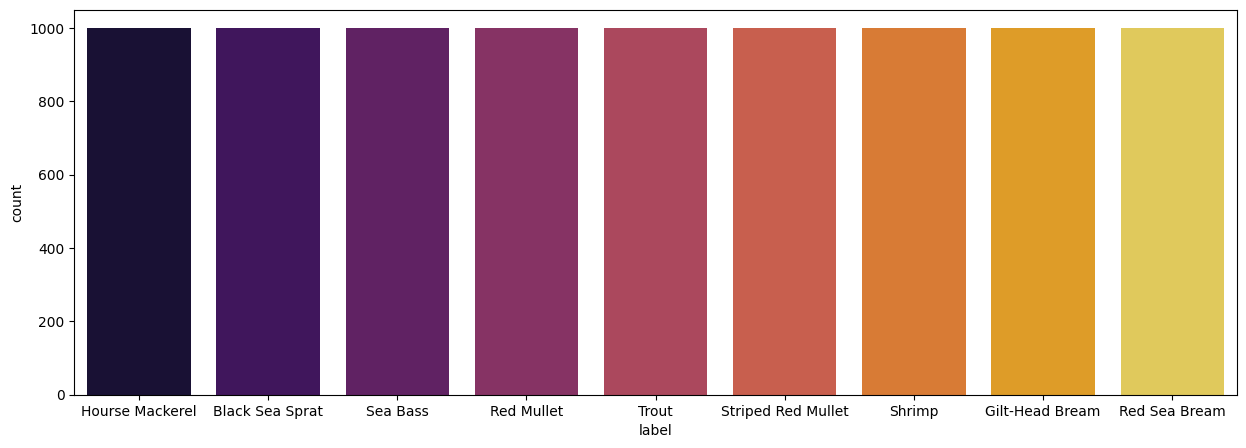

In [10]:
import seaborn as sns
order = df["label"].value_counts().index
plt.figure(figsize=(15,5))
sns.countplot(x="label",data=df,palette="inferno",order=order)
plt.show()

In [11]:
print(f"Toplam Veri(Görsel) Sayısı : {len(df)}")

Toplam Veri(Görsel) Sayısı : 9000


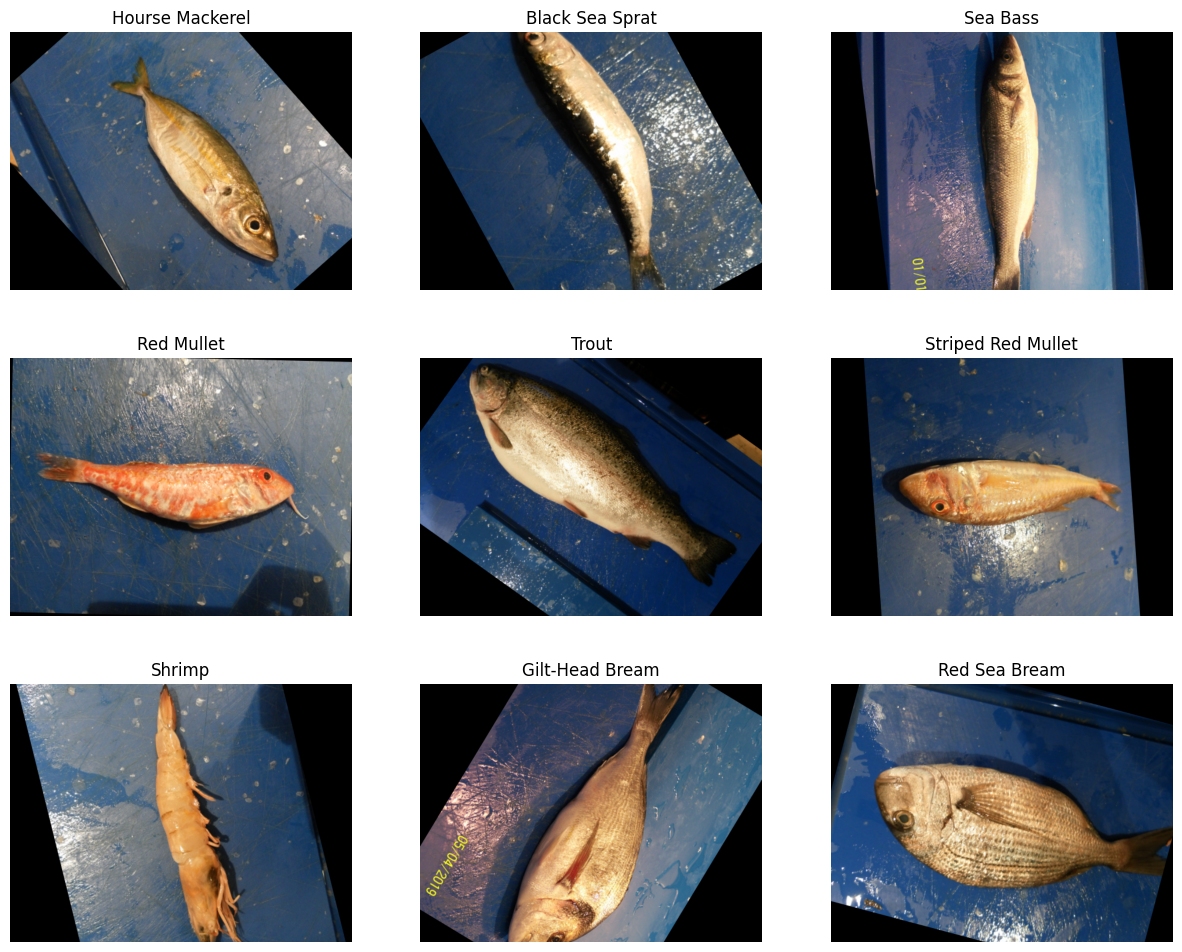

In [12]:
idx = 0
plt.figure(figsize=(15,12))
for unique_label in df['label'].unique():
    plt.subplot(3, 3, idx+1)
    plt.imshow(plt.imread(df[df['label']==unique_label].iloc[0,0]))
    plt.title(unique_label)
    plt.axis('off')
    idx+=1

In [13]:
labels = df['label'].astype('category').cat.codes
df['label_encoded'] = labels

img_size = (128, 128)  

images = []
for img_path in df['path']:
    img = load_img(img_path, target_size=img_size) 
    img_array = img_to_array(img) / 255
    images.append(img_array)

X = np.array(images)
y = to_categorical(df['label_encoded'])  

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
X_train.shape

(7200, 128, 128, 3)

In [16]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),  
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),  
    MaxPooling2D((2, 2)),
    Flatten(input_shape=(128,128,3)),
    Dense(128, activation='relu',name="Layer1"),
    Dropout(0.5),
    Dense(9, activation='softmax',name="output_layer")  
])

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/conda/lib/python3.10/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=[tf.keras.metrics.Precision(),tf.keras.metrics.Recall(),"accuracy"])

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer1 (Dense)                  │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,481 (28.20 MB)

 Trainable params: 7,393,481 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=3,          
    restore_best_weights=True  
)

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=10,               
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping])

Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 106s 463ms/step - accuracy: 0.4014 - loss: 1.7101 - precision: 0.5828 - recall: 0.2012 - val_accuracy: 0.8911 - val_loss: 0.3818 - val_precision: 0.9313 - val_recall: 0.8289
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 104s 461ms/step - accuracy: 0.8380 - loss: 0.4593 - precision: 0.8821 - recall: 0.7940 - val_accuracy: 0.9583 - val_loss: 0.1678 - val_precision: 0.9696 - val_recall: 0.9400
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 103s 457ms/step - accuracy: 0.9282 - loss: 0.2194 - precision: 0.9438 - recall: 0.9085 - val_accuracy: 0.9650 - val_loss: 0.1157 - val_precision: 0.9730 - val_recall: 0.9617
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 140s 447ms/step - accuracy: 0.9544 - loss: 0.1369 - precision: 0.9613 - recall: 0.9447 - val_accuracy: 0.9706 - val_loss: 0.0934 - val_precision: 0.9726 - val_recall: 0.9656
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 99s 441ms/step - accuracy: 0.9629 - loss: 0.1056 - precision: 0.9669 - recall: 0.9581 - val_accuracy: 0.

In [21]:
results = model.evaluate(X_test, y_test)
test_loss, test_accuracy = results[0], results[1]
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - accuracy: 0.9934 - loss: 0.0360 - precision: 0.9934 - recall: 0.9934
Test Loss: 0.0246
Test Accuracy: 0.9939


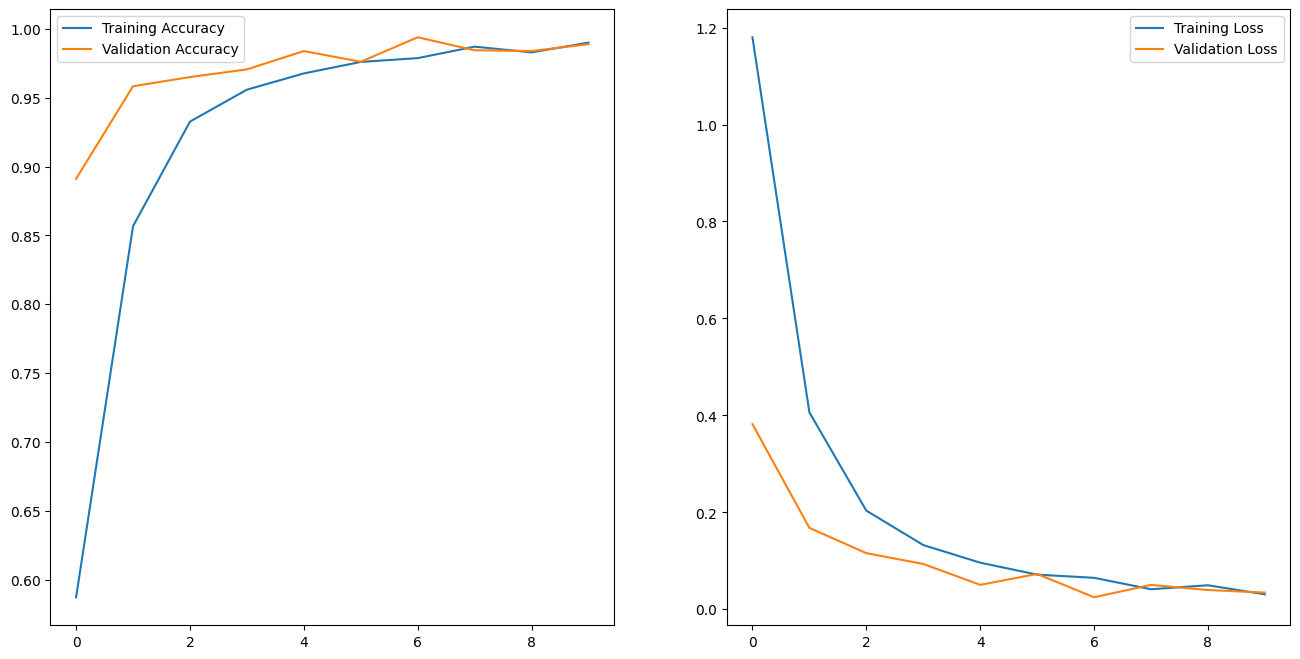

In [22]:
plt.figure(figsize=(16,8))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step


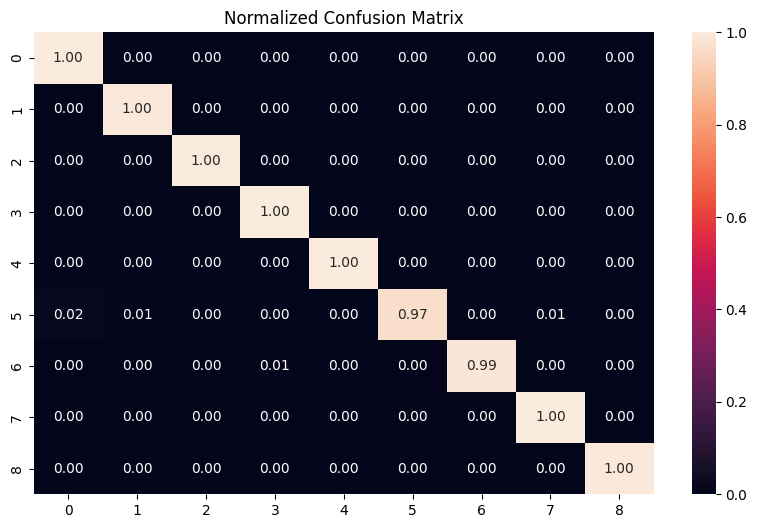

In [23]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)  
y_true = y_test.argmax(axis=1)  

cm = confusion_matrix(y_true, y_pred,normalize="true")
plt.figure(figsize = (10,6))
sns.heatmap(cm, annot=True,fmt='.2f')
plt.title('Normalized Confusion Matrix')
plt.show()

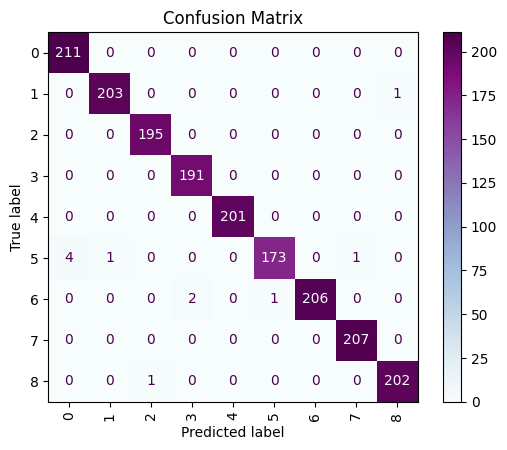

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="BuPu", xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

In [25]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       211
           1       1.00      1.00      1.00       204
           2       0.99      1.00      1.00       195
           3       0.99      1.00      0.99       191
           4       1.00      1.00      1.00       201
           5       0.99      0.97      0.98       179
           6       1.00      0.99      0.99       209
           7       1.00      1.00      1.00       207
           8       1.00      1.00      1.00       203

    accuracy                           0.99      1800
   macro avg       0.99      0.99      0.99      1800
weighted avg       0.99      0.99      0.99      1800



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


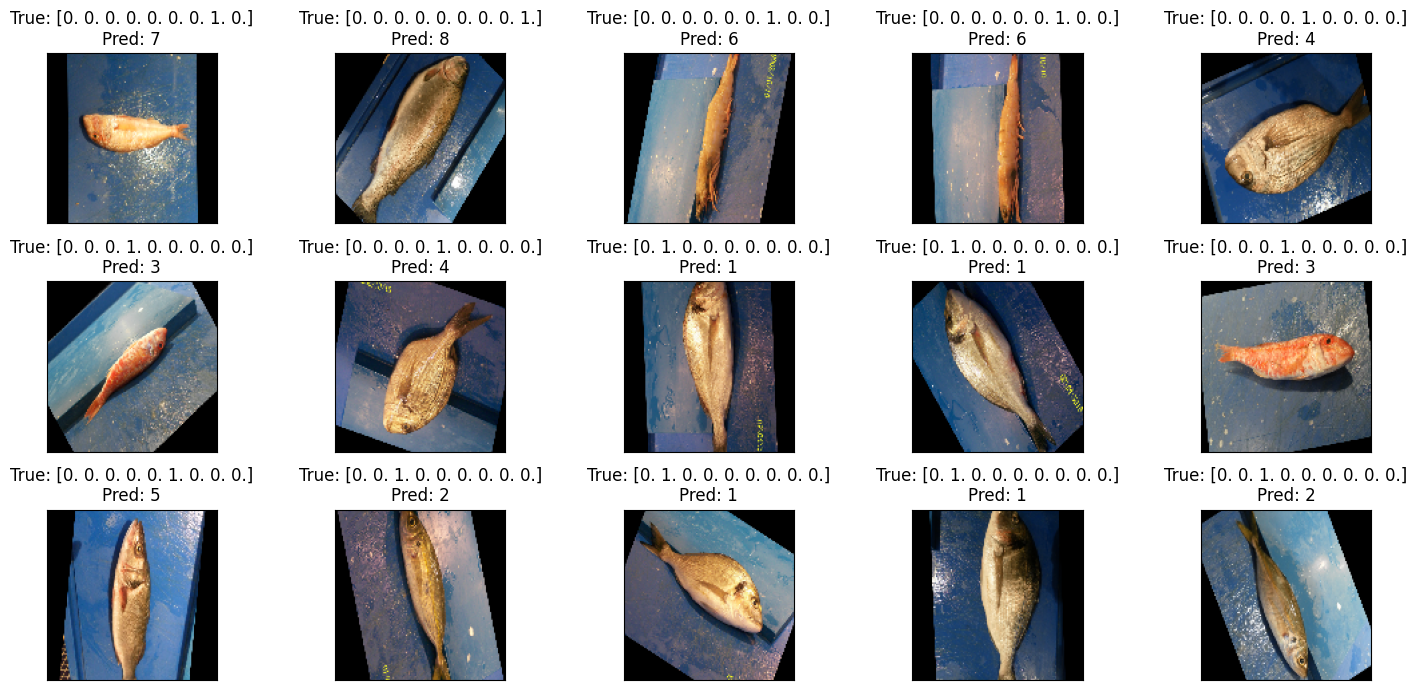

In [26]:
num_images = 15
indices = np.random.choice(len(X_test), num_images, replace=False)  
selected_images = X_test[indices]
true_labels = y_test[indices]
predicted_labels = np.argmax(model.predict(selected_images), axis=1)  


fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(15, 7), subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    img = selected_images[i]
    if img.shape[-1] == 1:  
        img = img.squeeze(-1) 
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}")
    
plt.tight_layout()
plt.show()